# Importing Dependencies

In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)
%matplotlib inline

# Data Collection

In [2]:
# Loading data
diabetes_data = pd.read_csv('Dataset of Diabetes .csv')

# Exploratory Data Analysis (EDA)

In [3]:
# Printing the first 5 rows of the dataframe
diabetes_data.head()

,ID,No_Pation,Gender,AGE,Urea,Cr,HbA1c,Chol,TG,HDL,LDL,VLDL,BMI,CLASS
0,502,17975,F,50,4.7,46,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
1,735,34221,M,26,4.5,62,4.9,3.7,1.4,1.1,2.1,0.6,23.0,N
2,420,47975,F,50,4.7,46,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
3,680,87656,F,50,4.7,46,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
4,504,34223,M,33,7.1,46,4.9,4.9,1.0,0.8,2.0,0.4,21.0,N


In [4]:
# number of the rows and columns in the dataframe
diabetes_data.shape

(1000, 14)

In [5]:
# getting more information about the dataset
diabetes_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   ID         1000 non-null   int64  
 1   No_Pation  1000 non-null   int64  
 2   Gender     1000 non-null   object 
 3   AGE        1000 non-null   int64  
 4   Urea       1000 non-null   float64
 5   Cr         1000 non-null   int64  
 6   HbA1c      1000 non-null   float64
 7   Chol       1000 non-null   float64
 8   TG         1000 non-null   float64
 9   HDL        1000 non-null   float64
 10  LDL        1000 non-null   float64
 11  VLDL       1000 non-null   float64
 12  BMI        1000 non-null   float64
 13  CLASS      1000 non-null   object 
dtypes: float64(8), int64(4), object(2)
memory usage: 109.5+ KB


In [6]:
# Checking for missing value in each column
diabetes_data.isnull().sum()

ID           0
No_Pation    0
Gender       0
AGE          0
Urea         0
Cr           0
HbA1c        0
Chol         0
TG           0
HDL          0
LDL          0
VLDL         0
BMI          0
CLASS        0
dtype: int64

In [7]:
# getting some more information
diabetes_data.describe()

,ID,No_Pation,AGE,Urea,Cr,HbA1c,Chol,TG,HDL,LDL,VLDL,BMI
count,1000.000000,1.000000e+03,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,340.500000,2.705514e+05,53.528000,5.124743,68.943000,8.281160,4.862820,2.349610,1.204750,2.609790,1.854700,29.578020
std,240.397673,3.380758e+06,8.799241,2.935165,59.984747,2.534003,1.301738,1.401176,0.660414,1.115102,3.663599,4.962388
min,1.000000,1.230000e+02,20.000000,0.500000,6.000000,0.900000,0.000000,0.300000,0.200000,0.300000,0.100000,19.000000
25%,125.750000,2.406375e+04,51.000000,3.700000,48.000000,6.500000,4.000000,1.500000,0.900000,1.800000,0.700000,26.000000
50%,300.500000,3.439550e+04,55.000000,4.600000,60.000000,8.000000,4.800000,2.000000,1.100000,2.500000,0.900000,30.000000
75%,550.250000,4.538425e+04,59.000000,5.700000,73.000000,10.200000,5.600000,2.900000,1.300000,3.300000,1.500000,33.000000
max,800.000000,7.543566e+07,79.000000,38.900000,800.000000,16.000000,10.300000,13.800000,9.900000,9.900000,35.000000,47.750000


In [8]:
# distribution of target variable
diabetes_data['CLASS'].value_counts()

CLASS
Y    844
N    103
P     53
Name: count, dtype: int64

    Y ---> Diabetic
    N ---> Non-Diabetic
    P ---> Predict-Diabetic

In [9]:
# grouping the data based on the target variable
diabetes_data.groupby('CLASS').mean(numeric_only=True)

,ID,No_Pation,AGE,Urea,Cr,HbA1c,Chol,TG,HDL,LDL,VLDL,BMI
CLASS,,,,,,,,,,,,
N,368.252427,815851.990291,44.233010,4.680583,62.796117,4.560194,4.268932,1.625243,1.227184,2.625243,0.943689,22.374757
P,396.056604,64299.037736,43.283019,4.511321,66.075472,6.003774,4.579245,2.126415,1.127358,2.493396,0.983019,23.933962
Y,333.624408,216955.928910,55.305687,5.217468,69.873223,8.878270,4.953104,2.452026,1.206872,2.615213,2.020616,30.811517


# Data Pre-Processing

## Drop useless column

In [10]:
data = diabetes_data.drop(columns=['ID','No_Pation'], axis=1)

In [11]:
data

,Gender,AGE,Urea,Cr,HbA1c,Chol,TG,HDL,LDL,VLDL,BMI,CLASS
0,F,50,4.7,46,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
1,M,26,4.5,62,4.9,3.7,1.4,1.1,2.1,0.6,23.0,N
2,F,50,4.7,46,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
3,F,50,4.7,46,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
4,M,33,7.1,46,4.9,4.9,1.0,0.8,2.0,0.4,21.0,N
...,...,...,...,...,...,...,...,...,...,...,...,...
995,M,71,11.0,97,7.0,7.5,1.7,1.2,1.8,0.6,30.0,Y
996,M,31,3.0,60,12.3,4.1,2.2,0.7,2.4,15.4,37.2,Y
997,M,30,7.1,81,6.7,4.1,1.1,1.2,2.4,8.1,27.4,Y
998,M,38,5.8,59,6.7,5.3,2.0,1.6,2.9,14.0,40.5,Y


# Separating the features & Target

In [12]:
X = data.drop(columns=['CLASS'], axis=1)
Y = data['CLASS']

# Encode Gender and CLASS

In [13]:
# Encode Gender column (F->0, M->1)
le_gender = LabelEncoder()
X = X.copy()
X['Gender'] = le_gender.fit_transform(X['Gender'])

# Encode CLASS label (N->0, P->1, Y->2)
le_class = LabelEncoder()
Y = le_class.fit_transform(Y)

print('Gender encoding:', dict(zip(le_gender.classes_, le_gender.transform(le_gender.classes_))))
print('CLASS  encoding:', dict(zip(le_class.classes_, le_class.transform(le_class.classes_))))

Gender encoding: {'F': np.int64(0), 'M': np.int64(1), 'f': np.int64(2)}
CLASS  encoding: {'N': np.int64(0), 'P': np.int64(1), 'Y': np.int64(2)}


- F → 0
- M → 1
---
- N → 0
- P → 1
- Y → 2

# Splitting the data to training data & Test data

In [14]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y,
    test_size=0.2,
    random_state=2,
    stratify=Y
)
# Keep an unscaled copy of X_train for EDA (e.g. feature importance chart)
# so the analysis section never touches X_test or the full dataset.
X_train_raw = X_train.copy()

In [15]:
X.shape, X_train.shape, X_test.shape

((1000, 11), (800, 11), (200, 11))

# Feature selection

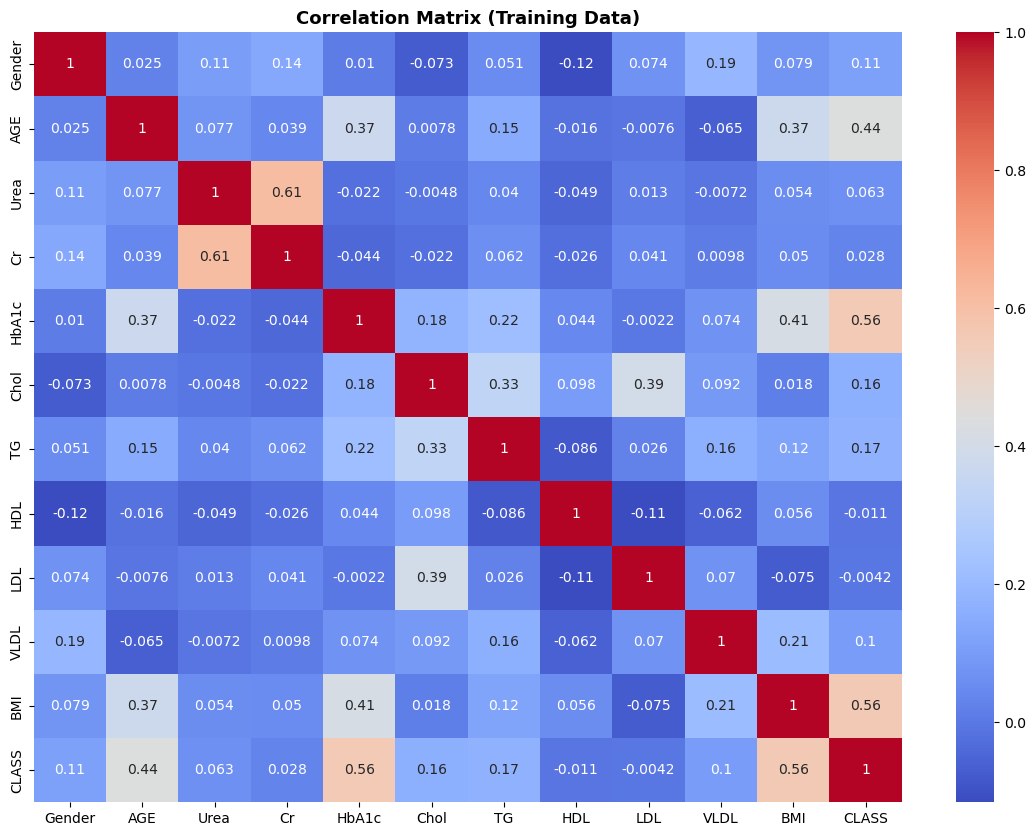

In [16]:
#display correlation matrix in heatmap
Y_train_series = pd.Series(Y_train, name='CLASS', index=X_train.index)
train_df = pd.concat([X_train, Y_train_series], axis=1)
corr_matrix = train_df.corr()
plt.figure(figsize=(14,10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix (Training Data)', fontsize=13, fontweight='bold')
plt.show()

In [17]:
# Use mutual information (MI) instead of Pearson correlation for feature selection.
# Pearson treats the encoded integers (N=0, P=1, Y=2) as an ordered numeric scale,
# which is not appropriate for a nominal 3-class target.
# MI measures statistical dependency regardless of numeric ordering.
from sklearn.feature_selection import mutual_info_classif

mi_scores = mutual_info_classif(X_train, Y_train, random_state=42)
mi_series = pd.Series(mi_scores, index=X_train.columns).sort_values(ascending=False)
print('Mutual Information scores (training data only):')
print(mi_series.to_string())
print()

# Keep features whose MI score is above 50% of the maximum score
mi_threshold = mi_series.max() * 0.10
selected_features = mi_series[mi_series >= mi_threshold].index
# Save a reference used by the EDA feature-importance chart (analysis section)
selected_features_raw = selected_features
print('MI threshold (10% of max):', round(mi_threshold, 4))
print('Selected Features:', list(selected_features))

Mutual Information scores (training data only):
HbA1c     0.384379
BMI       0.299000
AGE       0.208766
VLDL      0.067685
TG        0.056910
Urea      0.041664
Cr        0.036098
HDL       0.032981
Chol      0.021379
LDL       0.013937
Gender    0.009606

MI threshold (10% of max): 0.0384
Selected Features: ['HbA1c', 'BMI', 'AGE', 'VLDL', 'TG', 'Urea']


# Analysis

## 1. Diabetic vs Non-Diabetic vs Pre-Diabetic Patient Distribution

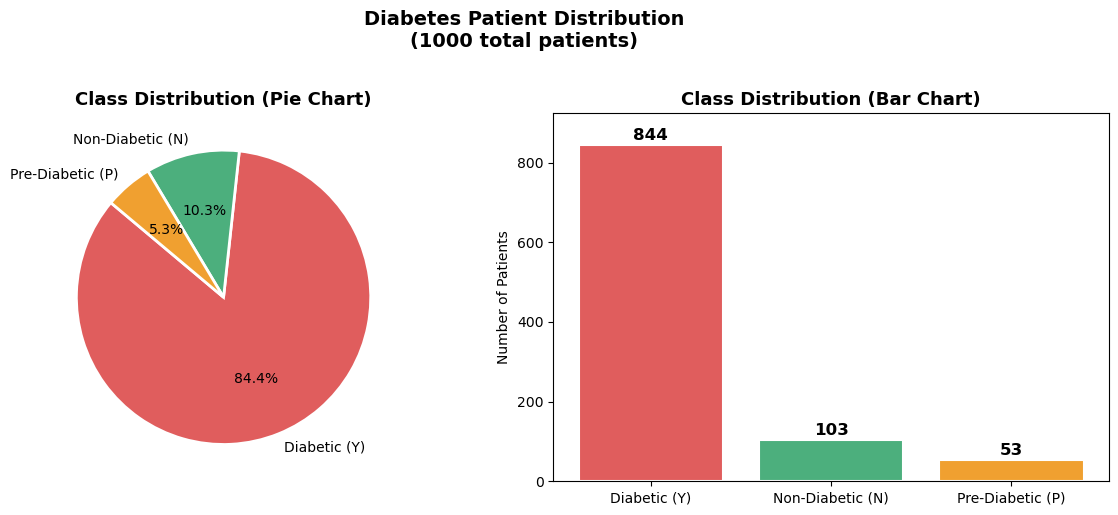

Diabetic     (Y): 844 (84.4%)
Non-Diabetic (N): 103 (10.3%)
Pre-Diabetic (P): 53 (5.3%)


In [18]:
# Class distribution
class_counts = diabetes_data['CLASS'].value_counts()
labels = ['Diabetic (Y)', 'Non-Diabetic (N)', 'Pre-Diabetic (P)']
values = [class_counts.get('Y', 0), class_counts.get('N', 0), class_counts.get('P', 0)]
colors = ['#e05d5d', '#4caf7d', '#f0a030']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Pie chart
axes[0].pie(
    values,
    labels=labels,
    autopct='%1.1f%%',
    colors=colors,
    startangle=140,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[0].set_title('Class Distribution (Pie Chart)', fontsize=13, fontweight='bold')

# Bar chart
bars = axes[1].bar(labels, values, color=colors, edgecolor='white', linewidth=1.5)
for bar, count in zip(bars, values):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5,
                 str(count), ha='center', va='bottom', fontweight='bold', fontsize=12)
axes[1].set_title('Class Distribution (Bar Chart)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Number of Patients')
axes[1].set_ylim(0, max(values) + 80)

plt.suptitle('Diabetes Patient Distribution\n(1000 total patients)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

total = len(diabetes_data)
print(f"Diabetic     (Y): {class_counts.get('Y',0)} ({class_counts.get('Y',0)/total*100:.1f}%)")
print(f"Non-Diabetic (N): {class_counts.get('N',0)} ({class_counts.get('N',0)/total*100:.1f}%)")
print(f"Pre-Diabetic (P): {class_counts.get('P',0)} ({class_counts.get('P',0)/total*100:.1f}%)")

## 2. Age & BMI Distribution by Class

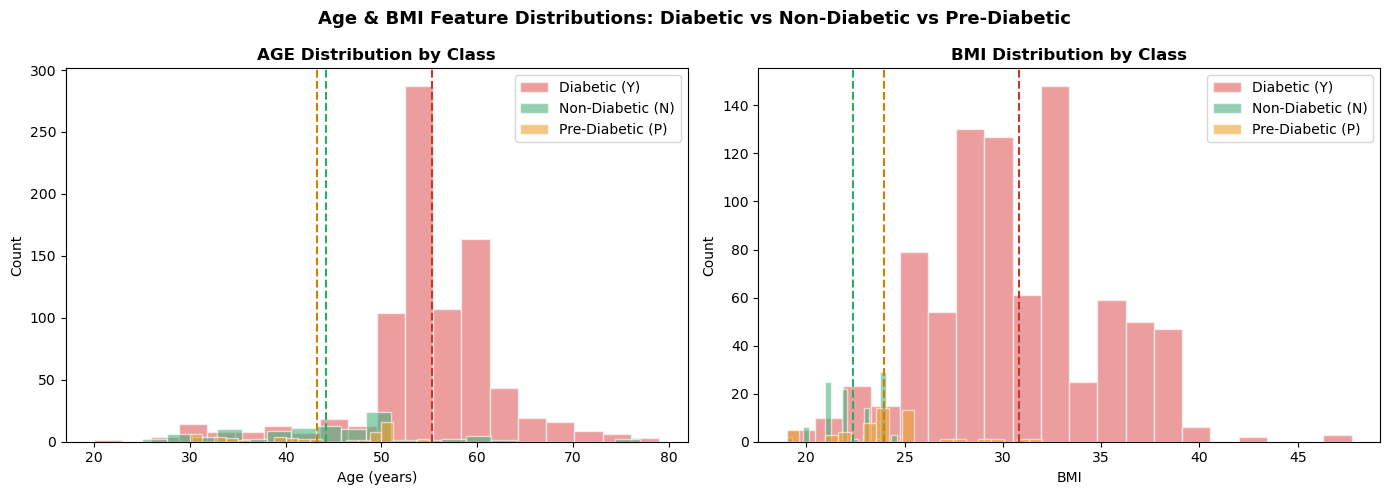

In [19]:
# Distribution of Age and BMI split by class
diabetic_data     = diabetes_data[diabetes_data['CLASS'] == 'Y']
non_diabetic_data = diabetes_data[diabetes_data['CLASS'] == 'N']
pre_diabetic_data = diabetes_data[diabetes_data['CLASS'] == 'P']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, feat, xlabel in zip(axes, ['AGE', 'BMI'], ['Age (years)', 'BMI']):
    ax.hist(diabetic_data[feat],     bins=20, alpha=0.6, color='#e05d5d', label='Diabetic (Y)',     edgecolor='white')
    ax.hist(non_diabetic_data[feat], bins=20, alpha=0.6, color='#4caf7d', label='Non-Diabetic (N)', edgecolor='white')
    ax.hist(pre_diabetic_data[feat], bins=20, alpha=0.6, color='#f0a030', label='Pre-Diabetic (P)', edgecolor='white')
    ax.axvline(diabetic_data[feat].mean(),     color='#c0392b', linestyle='--', linewidth=1.5)
    ax.axvline(non_diabetic_data[feat].mean(), color='#27ae60', linestyle='--', linewidth=1.5)
    ax.axvline(pre_diabetic_data[feat].mean(), color='#d08000', linestyle='--', linewidth=1.5)
    ax.set_title(f'{feat} Distribution by Class', fontsize=12, fontweight='bold')
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Count')
    ax.legend()

plt.suptitle('Age & BMI Feature Distributions: Diabetic vs Non-Diabetic vs Pre-Diabetic',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 3. Feature Mean Comparison Across Classes

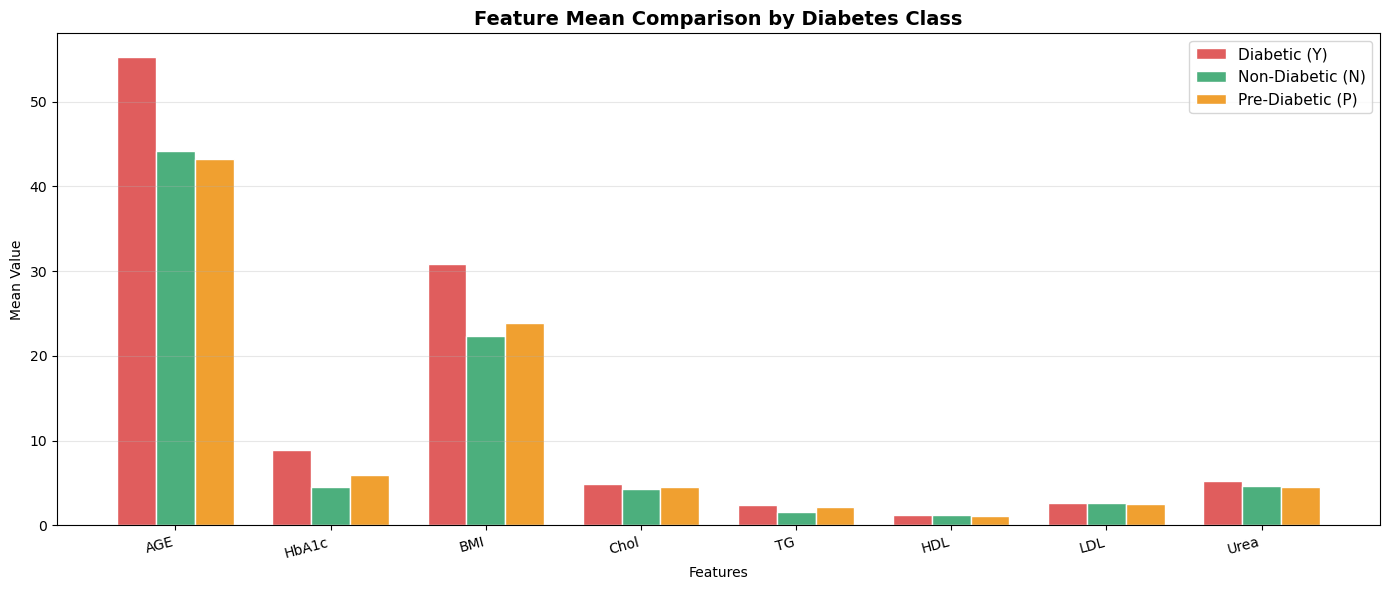

In [20]:
# Mean comparison of key clinical features across classes
key_features = ['AGE', 'HbA1c', 'BMI', 'Chol', 'TG', 'HDL', 'LDL', 'Urea']

group_means = diabetes_data.groupby('CLASS')[key_features].mean()
y_means = group_means.loc['Y']
n_means = group_means.loc['N']
p_means = group_means.loc['P']

x = range(len(key_features))
width = 0.25

fig, ax = plt.subplots(figsize=(14, 6))
ax.bar([i - width for i in x],     y_means.values, width, label='Diabetic (Y)',     color='#e05d5d', edgecolor='white')
ax.bar([i for i in x],             n_means.values, width, label='Non-Diabetic (N)', color='#4caf7d', edgecolor='white')
ax.bar([i + width for i in x],     p_means.values, width, label='Pre-Diabetic (P)', color='#f0a030', edgecolor='white')

ax.set_title('Feature Mean Comparison by Diabetes Class', fontsize=14, fontweight='bold')
ax.set_xlabel('Features')
ax.set_ylabel('Mean Value')
ax.set_xticks(list(x))
ax.set_xticklabels(key_features, rotation=15, ha='right', fontsize=10)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 4. HbA1c & BMI Distributions by Class (Box Plots)

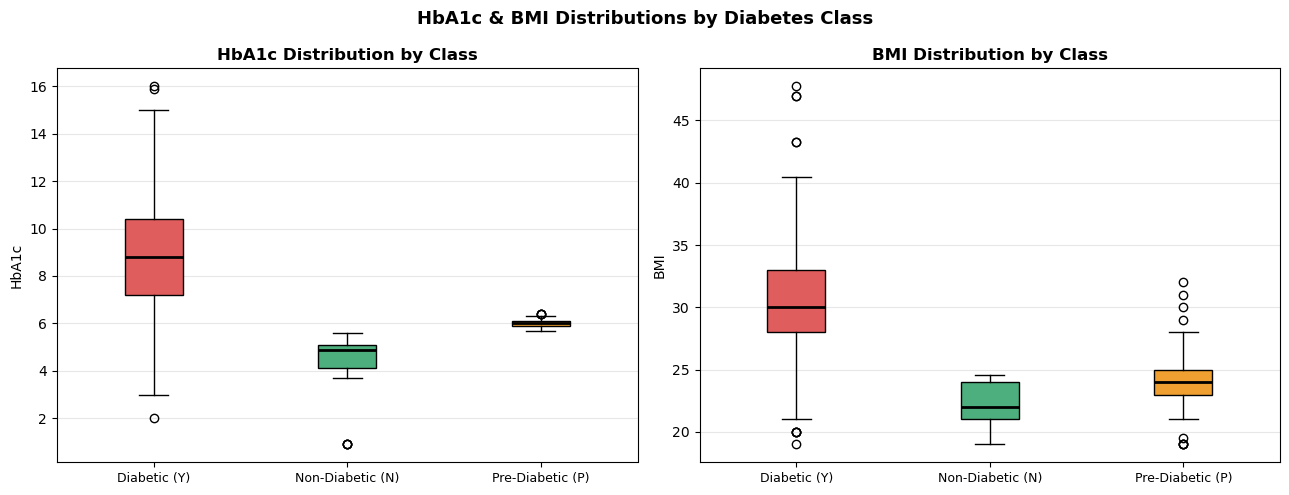

In [21]:
# Box plots for HbA1c and BMI grouped by class
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

hba1c_data = [diabetic_data['HbA1c'].values, non_diabetic_data['HbA1c'].values, pre_diabetic_data['HbA1c'].values]
bmi_data   = [diabetic_data['BMI'].values,   non_diabetic_data['BMI'].values,   pre_diabetic_data['BMI'].values]

tick_labels = ['Diabetic (Y)', 'Non-Diabetic (N)', 'Pre-Diabetic (P)']
box_colors  = ['#e05d5d', '#4caf7d', '#f0a030']

for ax, data_list, ylabel, title in zip(
    axes,
    [hba1c_data, bmi_data],
    ['HbA1c', 'BMI'],
    ['HbA1c Distribution by Class', 'BMI Distribution by Class']
):
    bp = ax.boxplot(data_list, tick_labels=tick_labels,
                    patch_artist=True, notch=False,
                    medianprops=dict(color='black', linewidth=2))
    for patch, color in zip(bp['boxes'], box_colors):
        patch.set_facecolor(color)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_ylabel(ylabel)
    ax.grid(axis='y', alpha=0.3)
    ax.tick_params(axis='x', labelsize=9)

plt.suptitle('HbA1c & BMI Distributions by Diabetes Class', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. HbA1c vs BMI Scatter Plot

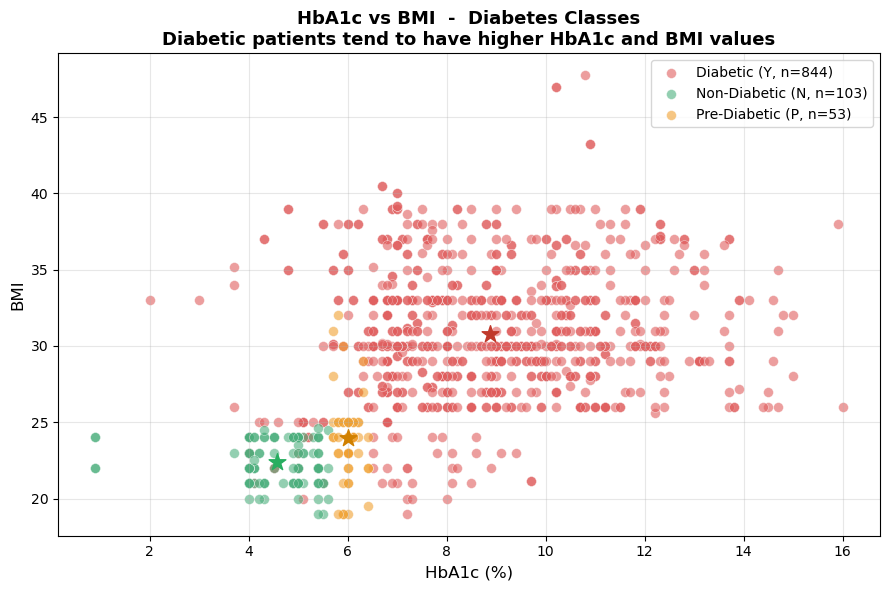

In [22]:
# HbA1c vs BMI scatter coloured by class
fig, ax = plt.subplots(figsize=(9, 6))

scatter_groups = [
    (diabetic_data,     '#e05d5d', f"Diabetic (Y, n={len(diabetic_data)})"),
    (non_diabetic_data, '#4caf7d', f"Non-Diabetic (N, n={len(non_diabetic_data)})"),
    (pre_diabetic_data, '#f0a030', f"Pre-Diabetic (P, n={len(pre_diabetic_data)})"),
]

mean_colors = ['#c0392b', '#27ae60', '#d08000']

for (grp, color, label), mcol in zip(scatter_groups, mean_colors):
    ax.scatter(grp['HbA1c'], grp['BMI'], c=color, alpha=0.6, s=50,
               edgecolors='white', linewidths=0.4, label=label)
    ax.scatter(grp['HbA1c'].mean(), grp['BMI'].mean(), c=mcol, s=160,
               marker='*', zorder=5)

ax.set_xlabel('HbA1c (%)', fontsize=12)
ax.set_ylabel('BMI', fontsize=12)
ax.set_title('HbA1c vs BMI  -  Diabetes Classes\n'
             'Diabetic patients tend to have higher HbA1c and BMI values',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Correlation Heatmap

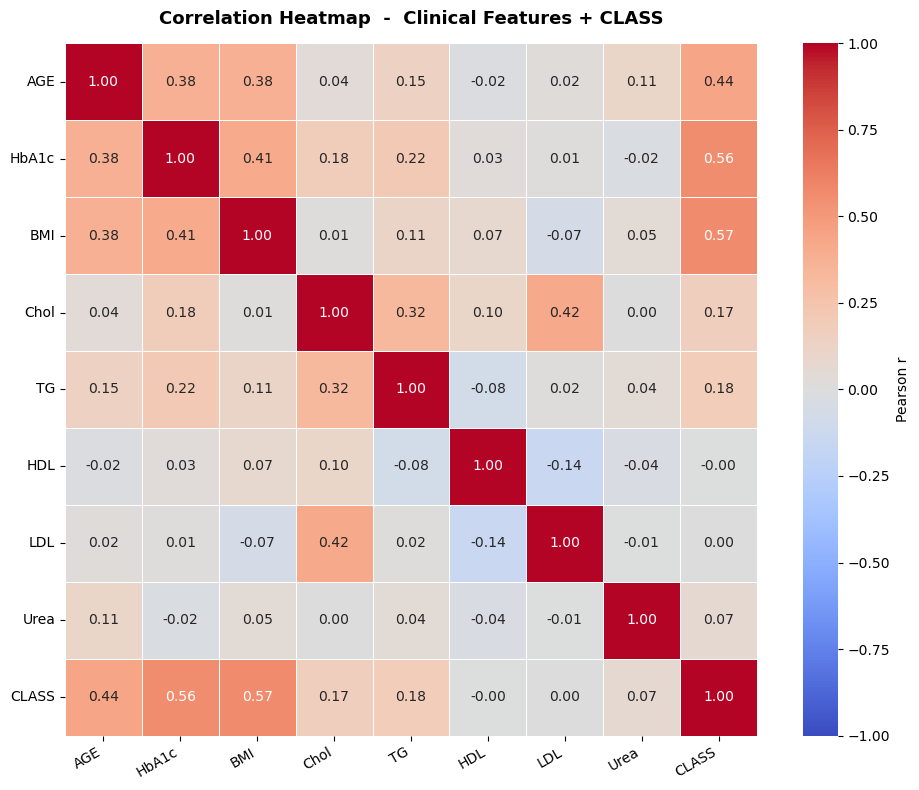

Top correlations with CLASS (abs):
BMI      0.569879
HbA1c    0.555321
AGE      0.443009
TG       0.182299
Chol     0.167375
Urea     0.067010
LDL      0.004247
HDL      0.001248


In [23]:
# Correlation heatmap of key clinical features including encoded CLASS
corr_cols = ['AGE', 'HbA1c', 'BMI', 'Chol', 'TG', 'HDL', 'LDL', 'Urea', 'CLASS']
corr_df_tmp = diabetes_data[corr_cols].copy()
corr_df_tmp['CLASS'] = le_class.transform(corr_df_tmp['CLASS'])
corr_mat = corr_df_tmp.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_mat,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    square=True,
    cbar_kws={'label': 'Pearson r'}
)
plt.title('Correlation Heatmap  -  Clinical Features + CLASS',
          fontsize=13, fontweight='bold', pad=14)
plt.xticks(rotation=30, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print('Top correlations with CLASS (abs):')
print(corr_mat['CLASS'].drop('CLASS').abs().sort_values(ascending=False).to_string())

## 7. Feature Importance (Random Forest)

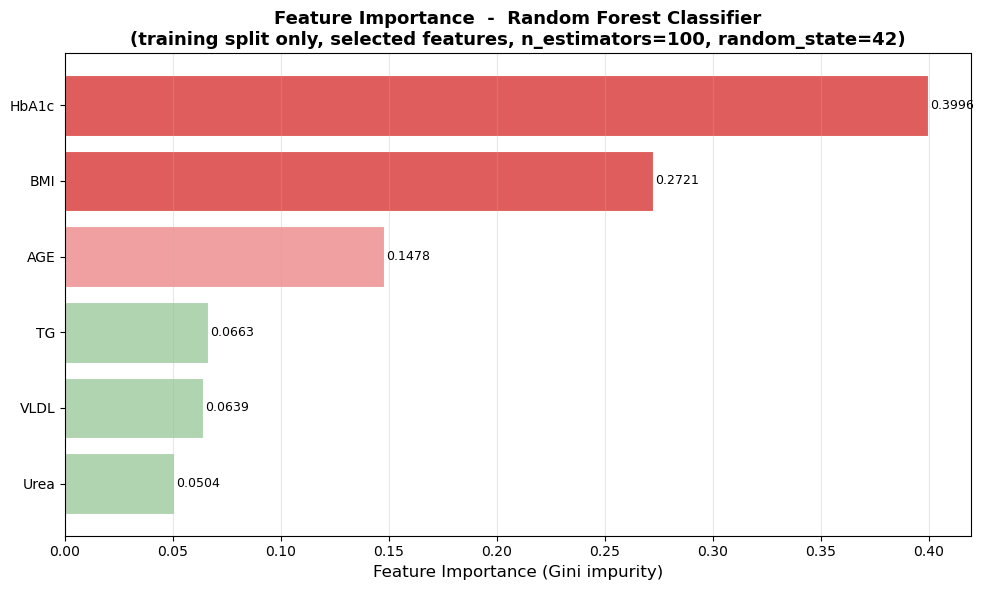


Top 5 most important features:
HbA1c    0.399577
BMI      0.272076
AGE      0.147809
TG       0.066304
VLDL     0.063865


In [24]:
# Feature importance using a Random Forest trained on TRAINING DATA ONLY
# NOTE: This cell is EDA/analysis only. The RF here uses the raw (unscaled)
# training split so that feature importances are not contaminated by test data.
from sklearn.ensemble import RandomForestClassifier as RFC

analysis_data   = X_train_raw[selected_features_raw]  # raw (unscaled) train features
analysis_labels = Y_train

rf_analysis = RFC(n_estimators=100, random_state=42)
rf_analysis.fit(analysis_data, analysis_labels)

importances = pd.Series(rf_analysis.feature_importances_, index=analysis_data.columns)
importances_sorted = importances.sort_values(ascending=True)

colors_imp = ['#e05d5d' if v >= importances.quantile(0.75) else
              '#f0a0a0' if v >= importances.median() else
              '#b0d4b0' for v in importances_sorted.values]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(importances_sorted.index, importances_sorted.values,
               color=colors_imp, edgecolor='white', linewidth=0.8)

for bar, val in zip(bars, importances_sorted.values):
    ax.text(val + 0.001, bar.get_y() + bar.get_height() / 2,
            f'{val:.4f}', va='center', fontsize=9)

ax.set_xlabel('Feature Importance (Gini impurity)', fontsize=12)
ax.set_title('Feature Importance  -  Random Forest Classifier\n'
             '(training split only, selected features, n_estimators=100, random_state=42)',
             fontsize=13, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print('\nTop 5 most important features:')
print(importances.sort_values(ascending=False).head(5).to_string())

In [25]:
# Apply Mutual Information feature selection
# Keep only features selected from the training data.
# Feature selection was calculated using X_train and Y_train only.
X_train = X_train[selected_features]
X_test  = X_test[selected_features]

print('X_train shape after feature selection:', X_train.shape)
print('X_test  shape after feature selection:', X_test.shape)

X_train shape after feature selection: (800, 6)
X_test  shape after feature selection: (200, 6)


## Data Standardization
The `StandardScaler` is embedded *inside* every Pipeline (CV, GridSearchCV,
and the final `best_estimator_`), so it is always fitted on training data only.
No standalone scaler is needed for the final model -- `best_pipeline` already
contains the fitted scaler and is the single artifact saved for deployment.

In [26]:
# This cell is kept for reference / exploratory work only.
# The final model (best_pipeline) contains its own fitted scaler;
# there is no need to apply a separate scaler for prediction.
# X_train_scaled / X_test_scaled are NOT used in the model-training section below.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Model Selection

## Comparing models with default hyperparameters using Pipeline + Cross-Validation
Each Pipeline bundles `StandardScaler + Classifier` so the scaler is re-fitted
on each training fold and never sees the validation fold.

In [27]:
# Build Pipelines: scaler is re-fitted on every CV training fold (no leakage)
pipelines = {
    'SVM': Pipeline([
        ('scaler', StandardScaler()),
        ('classifier', SVC(kernel='linear'))
    ]),
    'Random Forest': Pipeline([
        ('scaler', StandardScaler()),
        ('classifier', RandomForestClassifier(random_state=0))
    ]),
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('classifier', LogisticRegression(max_iter=1000))
    ]),
}

# StratifiedKFold preserves the class ratio in every fold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# CV on raw (unscaled) X_train -- scaler is re-fitted inside each fold
for name, pipe in pipelines.items():
    cv_scores = cross_val_score(pipe, X_train, Y_train, cv=skf, scoring='accuracy')
    mean_acc  = round(cv_scores.mean() * 100, 2)
    std_acc   = round(cv_scores.std()  * 100, 2)
    print(f'CV accuracies for {name}: {cv_scores}')
    print(f'Mean CV accuracy for {name}: {mean_acc} % (+/- {std_acc} %)')
    print('-' * 65)

CV accuracies for SVM: [0.91875 0.9125  0.89375 0.93125 0.91875]
Mean CV accuracy for SVM: 91.5 % (+/- 1.22 %)
-----------------------------------------------------------------
CV accuracies for Random Forest: [0.95625 0.98125 0.9625  0.96875 0.975  ]
Mean CV accuracy for Random Forest: 96.88 % (+/- 0.88 %)
-----------------------------------------------------------------
CV accuracies for Logistic Regression: [0.91875 0.9125  0.90625 0.9125  0.9125 ]
Mean CV accuracy for Logistic Regression: 91.25 % (+/- 0.4 %)
-----------------------------------------------------------------


## Inference: Observe which model has the highest mean CV accuracy with default hyperparameters.

## Hyperparameter Tuning with GridSearchCV (Pipeline-based)
Parameters are prefixed with `classifier__` to target the classifier step inside the Pipeline.

In [28]:
# Hyperparameter grids  -- keys use classifier__ prefix for Pipeline compatibility
param_grids = {
    'SVM': {
        'classifier__kernel': ['linear', 'poly', 'rbf', 'sigmoid'],
        'classifier__gamma':  [0.1, 0.01, 'scale'],
        'classifier__C':      [1, 5, 10, 20],
    },
    'Random Forest': {
        'classifier__n_estimators': [10, 20, 50, 100],
    },
    'Logistic Regression': {
        'classifier__C': [1, 5, 10, 20],
    },
}

In [29]:
# Run GridSearchCV for each model inside its Pipeline.
# We store each fitted GridSearchCV object so the best estimator (pipeline)
# can be extracted directly -- no hard-coded hyperparameters.
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

gs_objects  = {}   # name -> fitted GridSearchCV object
gs_results  = []
for name, pipe in pipelines.items():
    gs = GridSearchCV(pipe, param_grids[name], cv=skf, scoring='accuracy', n_jobs=-1)
    gs.fit(X_train, Y_train)   # raw X_train -- scaler handled inside Pipeline
    gs_objects[name] = gs
    gs_results.append({
        'Model':         name,
        'Best CV Score': round(gs.best_score_ * 100, 2),
        'Best Params':   gs.best_params_,
    })
    print(f'{name}: best CV acc = {gs.best_score_*100:.2f}%  params = {gs.best_params_}')

gs_df = pd.DataFrame(gs_results)
print()
print(gs_df[['Model', 'Best CV Score']].to_string(index=False))

SVM: best CV acc = 93.25%  params = {'classifier__C': 20, 'classifier__gamma': 'scale', 'classifier__kernel': 'rbf'}
Random Forest: best CV acc = 97.50%  params = {'classifier__n_estimators': 20}
Logistic Regression: best CV acc = 91.38%  params = {'classifier__C': 5}

              Model  Best CV Score
                SVM          93.25
      Random Forest          97.50
Logistic Regression          91.38


## Inference
GridSearchCV with Pipeline identifies the best hyperparameters for each model.
The `gs_objects` dict holds each fitted `GridSearchCV`; `gs.best_estimator_` is the
tuned Pipeline (StandardScaler + Classifier) re-trained on the full training set.
We evaluate all three on the held-out test set below and automatically select the winner.

# Model Training & Evaluation

## Evaluate All Models on the Test Set
Best hyperparameters come directly from GridSearchCV -- nothing is hard-coded.
Each `best_estimator_` is a Pipeline that already contains the fitted scaler.

In [30]:
# -----------------------------------------------------------------------
# Evaluate every model on the held-out test set.
# Each best_estimator_ is the Pipeline (StandardScaler + Classifier)
# that GridSearchCV re-fitted on the full training set with the best params.
# We predict directly from the Pipeline so no manual scaling is needed.
# -----------------------------------------------------------------------

label_names   = list(le_class.classes_)          # ['N', 'P', 'Y']
eval_results  = []                               # collect per-model metrics
fitted_models = {}                               # name -> best_estimator_ pipeline

for name, gs in gs_objects.items():
    best_pipe = gs.best_estimator_               # Pipeline already contains scaler
    fitted_models[name] = best_pipe
    Y_pred = best_pipe.predict(X_test)           # raw X_test; scaler inside pipeline
    acc  = accuracy_score(Y_test, Y_pred) * 100
    prec = precision_score(Y_test, Y_pred, average='weighted') * 100
    rec  = recall_score(Y_test, Y_pred, average='weighted') * 100
    f1   = f1_score(Y_test, Y_pred, average='weighted') * 100
    best_cv = gs.best_score_ * 100
    eval_results.append({
        'Model':         name,
        'Best Params':   {k.replace('classifier__', ''): v for k, v in gs.best_params_.items()},
        'Best CV Acc':   round(best_cv, 2),
        'Test Acc':      round(acc,  2),
        'Precision':     round(prec, 2),
        'Recall':        round(rec,  2),
        'F1':            round(f1,   2),
        'Y_pred':        Y_pred,
    })
    print(f'=== {name} ===')
    print(f'  Best params  : {gs.best_params_}')
    print(f'  Best CV Acc  : {best_cv:.2f} %')
    print(f'  Test Acc     : {acc:.2f} %')
    print(f'  Precision    : {prec:.2f} %')
    print(f'  Recall       : {rec:.2f} %')
    print(f'  F1 Score     : {f1:.2f} %')
    print('  Confusion Matrix:')
    print(confusion_matrix(Y_test, Y_pred))
    print(classification_report(Y_test, Y_pred, target_names=label_names))
    print('-' * 70)

=== SVM ===
  Best params  : {'classifier__C': 20, 'classifier__gamma': 'scale', 'classifier__kernel': 'rbf'}
  Best CV Acc  : 93.25 %
  Test Acc     : 97.00 %
  Precision    : 97.31 %
  Recall       : 97.00 %
  F1 Score     : 97.02 %
  Confusion Matrix:
[[ 21   0   0]
 [  0   8   2]
 [  4   0 165]]
              precision    recall  f1-score   support

           N       0.84      1.00      0.91        21
           P       1.00      0.80      0.89        10
           Y       0.99      0.98      0.98       169

    accuracy                           0.97       200
   macro avg       0.94      0.93      0.93       200
weighted avg       0.97      0.97      0.97       200

----------------------------------------------------------------------
=== Random Forest ===
  Best params  : {'classifier__n_estimators': 20}
  Best CV Acc  : 97.50 %
  Test Acc     : 97.50 %
  Precision    : 97.68 %
  Recall       : 97.50 %
  F1 Score     : 97.49 %
  Confusion Matrix:
[[ 21   0   0]
 [  0   8   2]


## Model Selection Conclusion
The code cell below automatically builds the comparison table and selects the
model with the highest **test-set** accuracy.  Nothing is hard-coded.

In [31]:
# ------------------------------------------------------------------
# Automatically build the comparison table and select the best model.
# The winner is the model with the highest test-set accuracy.
# ------------------------------------------------------------------
comp_df = pd.DataFrame([
    {
        'Model':          r['Model'],
        'Best Params':    str(r['Best Params']),
        'Best CV Acc %':  r['Best CV Acc'],
        'Test Acc %':     r['Test Acc'],
        'Precision %':    r['Precision'],
        'Recall %':       r['Recall'],
        'F1 %':           r['F1'],
    }
    for r in eval_results
]).sort_values('Test Acc %', ascending=False).reset_index(drop=True)

print('=== Model Comparison (sorted by Test Accuracy) ===')
print(comp_df.to_string(index=False))
print()

# Identify the winner
best_row        = comp_df.iloc[0]
best_model_name = best_row['Model']
best_pipeline   = fitted_models[best_model_name]   # Pipeline: scaler + classifier

print(f'>>> Selected model : {best_model_name}')
print(f'    Best CV Acc    : {best_row["Best CV Acc %"]} %')
print(f'    Test Accuracy  : {best_row["Test Acc %"]} %')
print(f'    Best Params    : {best_row["Best Params"]}')

=== Model Comparison (sorted by Test Accuracy) ===
              Model                                  Best Params  Best CV Acc %  Test Acc %  Precision %  Recall %  F1 %
      Random Forest                         {'n_estimators': 20}          97.50        97.5        97.68      97.5 97.49
                SVM {'C': 20, 'gamma': 'scale', 'kernel': 'rbf'}          93.25        97.0        97.31      97.0 97.02
Logistic Regression                                     {'C': 5}          91.38        94.0        94.54      94.0 92.82

>>> Selected model : Random Forest
    Best CV Acc    : 97.5 %
    Test Accuracy  : 97.5 %
    Best Params    : {'n_estimators': 20}


## Building the Predictive System

In [32]:
# -- Predictive System -------------------------------------------------------
# Uses best_pipeline (the auto-selected Pipeline: StandardScaler + best Classifier)
# The Pipeline handles scaling internally -- no separate scaler call needed.
# Gender must be encoded (F=0, M=1) before calling.
# Feature order must match selected_features exactly.

LABEL_MAP = {'Y': 'Diabetic', 'N': 'Non-Diabetic', 'P': 'Pre-Diabetic'}

def predict_diabetes(input_values,
                     pipeline=None,
                     feature_names=None,
                     label_encoder=None):
    """
    Predict diabetes class for one patient.

    Parameters
    ----------
    input_values  : list / tuple matching feature_names order.
                    Gender must already be encoded (F=0, M=1).
    pipeline      : fitted sklearn Pipeline (scaler + classifier). Defaults to best_pipeline.
    feature_names : list of feature names. Defaults to list(selected_features).
    label_encoder : fitted LabelEncoder for the target. Defaults to le_class.

    Returns
    -------
    str - 'Diabetic', 'Non-Diabetic', or 'Pre-Diabetic'
    """
    if pipeline is None:
        pipeline = best_pipeline
    if feature_names is None:
        feature_names = list(selected_features)
    if label_encoder is None:
        label_encoder = le_class
    df = pd.DataFrame([input_values], columns=feature_names)
    prediction = pipeline.predict(df)[0]          # pipeline scales internally
    label = label_encoder.inverse_transform([prediction])[0]
    return LABEL_MAP.get(label, label)


# -- Example: first row of the test set -------------------------------------
sample_idx   = X_test.index[0]
sample_input = X_test.loc[sample_idx].tolist()   # already selected & unscaled
true_encoded = int(Y_test[list(X_test.index).index(sample_idx)])
true_label   = LABEL_MAP.get(le_class.inverse_transform([true_encoded])[0], 'Unknown')

result = predict_diabetes(sample_input)
print(f'Selected model  : {best_model_name}')
print('Input features  :', dict(zip(list(selected_features), sample_input)))
print('Predicted label :', result)
print('True label      :', true_label)

Selected model  : Random Forest
Input features  : {'HbA1c': 9.9, 'BMI': 28.0, 'AGE': 61.0, 'VLDL': 1.1, 'TG': 4.2, 'Urea': 2.1}
Predicted label : Diabetic
True label      : Diabetic


# Saving the trained model

In [33]:
import pickle

# Save a single deployment bundle containing everything needed for inference:
#   - best_pipeline   : Pipeline(StandardScaler + best Classifier)  -- handles scaling
#   - le_class        : LabelEncoder for the target (decodes 0/1/2 -> N/P/Y)
#   - selected_features: ordered list of input features
#   - best_model_name : string name of the winner (for logging / documentation)
#
# A single deployment_pipeline.pkl eliminates the risk of applying the wrong
# scaler or wrong feature set at inference time.

deployment_bundle = {
    'pipeline':          best_pipeline,
    'label_encoder':     le_class,
    'selected_features': list(selected_features),
    'best_model_name':   best_model_name,
}
pickle.dump(deployment_bundle, open('deployment_pipeline.pkl', 'wb'))

print(f'Saved: deployment_pipeline.pkl')
print(f'  Winner model     : {best_model_name}')
print(f'  Selected features: {list(selected_features)}')
print()
print('Usage at inference time:')
print('  bundle = pickle.load(open("deployment_pipeline.pkl", "rb"))')
print('  pred   = bundle["pipeline"].predict(input_df)[0]')
print('  label  = bundle["label_encoder"].inverse_transform([pred])[0]')

Saved: deployment_pipeline.pkl
  Winner model     : Random Forest
  Selected features: ['HbA1c', 'BMI', 'AGE', 'VLDL', 'TG', 'Urea']

Usage at inference time:
  bundle = pickle.load(open("deployment_pipeline.pkl", "rb"))
  pred   = bundle["pipeline"].predict(input_df)[0]
  label  = bundle["label_encoder"].inverse_transform([pred])[0]
